-0.0408


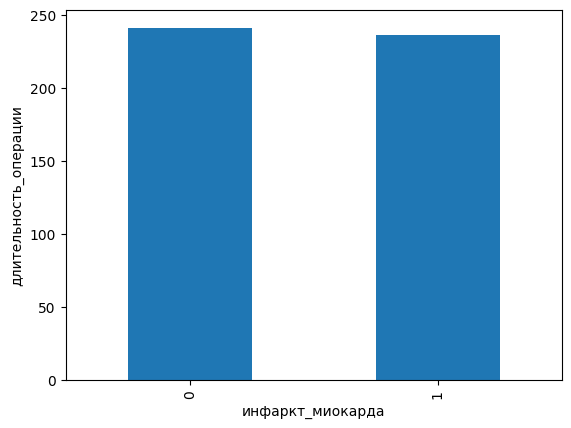

In [ ]:
import pandas as pd
import numpy as np

# Сброс ограничений на количество выводимых рядов
pd.set_option('display.max_rows', None)
 
# Сброс ограничений на число столбцов
pd.set_option('display.max_columns', None)
 
# Сброс ограничений на количество символов в записи
pd.set_option('display.max_colwidth', None)

data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace(',', '')
data['развитие_опп']=data['развитие_опп'].map({'нет':0,'есть':1})

#исправил столбец чсс с object на int
data["чсс"] = data["чсс"].apply(lambda x: 70 if x == "7o" else x)
data['чсс'] = data['чсс'].astype(int)

#исправил столбец рн с object на float
data['рн'] = data['рн'].apply(lambda x: float(x.replace(",", ".")) if "," in x else float(x))
data['рн'] = data['рн'].astype(float)

#столбец с людьми использовавшими АИК
data
#print(data[data["аик"] == 1]['аик'])


#замена пропусков на median
# print(data.isnull().sum().sum()) команда считающая количество Nan
columns_types_series = data.dtypes # все типы столбцов в виде series
count = 0
for i in data.columns:
    if columns_types_series[count] != "object": #заполняем все пропуски на медиану, кроме столбцов object
        data[i] = data[i].fillna(data[i].median())
    count += 1

#удаление явных дубликатов, но я не проверил, удалились ли дубликаты
data = data.drop_duplicates()
#------------------------------------------------------------------------------------
#3.3
#1 способ
import matplotlib.pyplot as plt

df = data[['инфаркт_миокарда', 'длительность_операции']]
grouped = df.groupby('инфаркт_миокарда')['длительность_операции'].mean()
plt.ylabel('длительность_операции')
grouped.plot(kind='bar')
#2 способ
first='длительность_операции'
second='инфаркт_миокарда'
new=data[[first,second]]
correlation = round(new[first].corr(new[second]),4)
print(correlation)

#данные по двум случаям близки по значениям, следовательно разницу между временем можно считать за погрешность
#ДЛИТЕЛЬНОСТЬ ОПЕРАЦИИИ НЕ ЗАВИСИТ ОТ ФАКТА ПЕРЕНЕСËННОГО РАНЕЕ ИНФАРКТА МИОКАРДА

In [ ]:
#3.4 
#верно ли, что у пациентов с ИМТ выше нормы будет повышенный 
#уровень холестерина?
#челы с имт выше нормы фул таблица:
high_bmi = data[data['имт'] > 25]
high_xolesterin = data[data['холестерин'] > 7.8] #3,6-7,8
high_bmi_with_high_xolesterin = high_bmi[high_bmi['холестерин'] > 7.8]
print(len(high_bmi_with_high_xolesterin)) #2
print(len(high_bmi)) #159
print(len(high_xolesterin)) #3
#количество пациентов с различными значениями уровня холестерина
#high_bmi['холестерин'].value_counts()

'''
вывод: 
имт зависит от большого количества факторов и необезательно,что у человека с имт выше нормы
будет повышенных холестерин

1) во всей таблице у 3х человек уровень холестерина выше нормы. 
2) из 3х этих человек у 2х имт выше нормы
3) пациенты с ИМТ выше нормы - 159
4) если из 159 холестерина выше нормы только у 2х значит ответ - не верно. 
НО у большинства людей с повышенным холестеринов ИМТ будтет выше нормы.
5) мало данных для более точного вывода
'''


2
159
3


'\nвывод: \nимт зависит от большого количества факторов и необезательно,что у человека с имт выше нормы\nбудет повышенных холестерин\n\n1) во всей таблице у 3х человек уровень холестерина выше нормы. \n2) из 3х этих человек у 2х имт выше нормы\n3) пациенты с ИМТ выше нормы - 159\n4) если из 159 холестерина выше нормы только у 2х значит ответ - не верно. \nНО у большинства людей с повышенным холестеринов ИМТ будтет выше нормы.\n5) мало данных для более точного вывода\n'

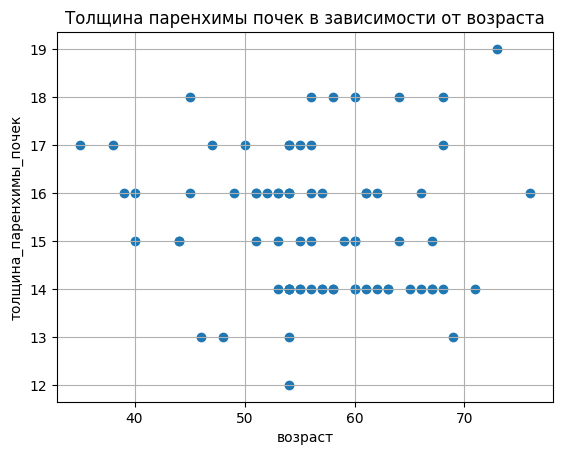

0.0982


'\nвывод: \nневерно, так как мы не может наблюдать определенную тенденцию к уменьшению, \nзначение толщины то уменьшается, то увеличивается в зависимости от возраста.\nтакже, если рассмотреть корреляцию в отфильтрованной таблице по этим двум параметрам, \nто она 0,0982 - это мало, значит вывод верен\n\nу людей без хбп толщина паренхимы не зависит от возраста\n'

In [ ]:
#3.5
#верно ли, что даже без хронических болезней почек с возрастом 
#толщина паренхимы почек уменьшается
import matplotlib.pyplot as plt

data['хбп']=data['хбп'].map({'Пациенты без ХБП':0,'Стадия C1-C2':1,'Стадия C3':2})
def check(a,b):
    if b>=90 and a!=0:
        return True
    elif 90>b>=60 and a!=1:
        return True
    elif 60>b>=30 and a!=2:
        return True
    return False

def need(a,b):
    if b>=90 and a!=0:
        return 0
    elif 90>b>=60 and a!=1:
        return 1
    elif 60>b>=30 and a!=2:
        return 2
    return 3
k=0
for index, row in data.iterrows():
    a=data.loc[index,'хбп']
    b=data.loc[index,'скф_расч.']
    if check(a,b):
        k+=1
        data.loc[index,'хбп']=need(a,b)



no_hbp_people = data[data['хбп'] == 0]

# Строим точечную диаграмму
plt.scatter(no_hbp_people['возраст'], no_hbp_people['толщина_паренхимы_почек'])
plt.xlabel('возраст')
plt.ylabel('толщина_паренхимы_почек')
plt.title('Толщина паренхимы почек в зависимости от возраста')
plt.grid(True)
plt.show()
correlation = round(no_hbp_people['толщина_паренхимы_почек'].corr(no_hbp_people['возраст']),4)
print(abs(correlation))
'''
вывод: 
неверно, так как мы не может наблюдать определенную тенденцию к уменьшению, 
значение толщины то уменьшается, то увеличивается в зависимости от возраста.
также, если рассмотреть корреляцию в отфильтрованной таблице по этим двум параметрам, 
то она 0,0982 - это мало, значит вывод верен

у людей без хбп толщина паренхимы не зависит от возраста
'''

0.0442


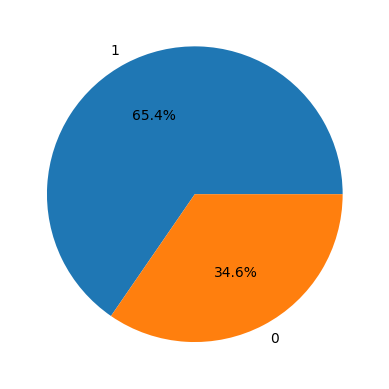

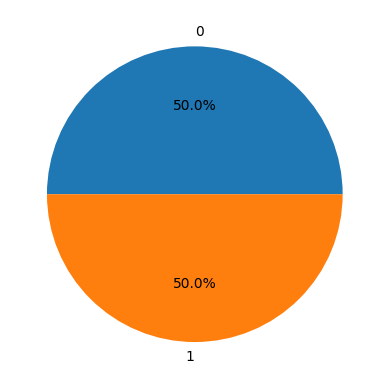

17
14
182
110


'\n14/17 = 0.8235\n110/182 = 0.604\n\nв первоначальной таблице кол-во женщин не равно кол-ву мужчин -> \nпоэтоу сравниваю процент среди женщин и мужчин.\nПолучаю, что вероятность заболеть женщине больше.\n'

In [ ]:
'''
Гипотеза 1 (биохимия): Влияет ли массса миокарда левого желудочка на развитие ОПП?
'''
correlation1 = round(data['развитие_опп'].corr(data['масса_миокарда_лж']),4)
print(correlation1) 
#0.0442 -> развитие опп в малой степени зависит от массса миокарда левого желудочка на развитие ОПП?
# если это вопрос, то да, считай что корреляции нет (ответ от Игоря)
'''
Гипотеза 2 (интраоперационные параметры): Влияет ли наличие АИК на развитие ОПП?
'''
have_AIK = data[data['аик'] == 1] #смотрю сколько из этих имеют опп
have_AIK = have_AIK[['аик','развитие_опп']]
k1 = have_AIK['развитие_опп'].value_counts(normalize=True)
f1 = plt.pie(k1, labels=k1.index.unique(), autopct='%1.1f%%')
plt.show()
#Среди тех, кто сделал АИК у 65% развился ОПП -> да влияет
'''

'''
have_AIK = data[data['аик'] == 0] #смотрю сколько из этих имеют опп
have_AIK = have_AIK[['аик','развитие_опп']]
k1 = have_AIK['развитие_опп'].value_counts(normalize=True)
f1 = plt.pie(k1, labels=k1.index.unique(), autopct='%1.1f%%')
plt.show()


'''
Сравнив два графика, где в первом показана доля людей заболевших и у которх во время лечения применялся АИК, 
а на втором люди которые лечились без АИК.
Из графиков видно, что среди людей к которым применялся АИК доля заболевших заметно выше (на более чем 15%)=>
=>можно сделать вывод, что использование АИК при лечении действительно влияет на риск развития заболевания.
'''

'''
Гипотеза 3 (анамнес): Верно ли, что у женщин вероятнее развитие ОПП?
'''

have_OPP = data[data['развитие_опп'] == 1] 
woman = data[data['пол'] == 0] #17
print(len(woman))
woman_OPP = have_OPP[have_OPP['пол']==0] #14
print(len(woman_OPP))
man = data[data['пол'] == 1] #182
print(len(man))
man_OPP = have_OPP[have_OPP['пол']==1] #110
print(len(man_OPP)) 
'''
14/17 = 0.8235
110/182 = 0.604

в первоначальной таблице кол-во женщин не равно кол-ву мужчин -> 
поэтоу сравниваю процент среди женщин и мужчин.
Получаю, что вероятность заболеть женщине больше.
'''
# have_AIK = have_AIK[['аик','развитие_опп']]
# k1 = have_AIK['развитие_опп'].value_counts(normalize=True)
# f1 = plt.pie(k1, labels=k1.index.unique(), autopct='%1.1f%%')
# plt.show()


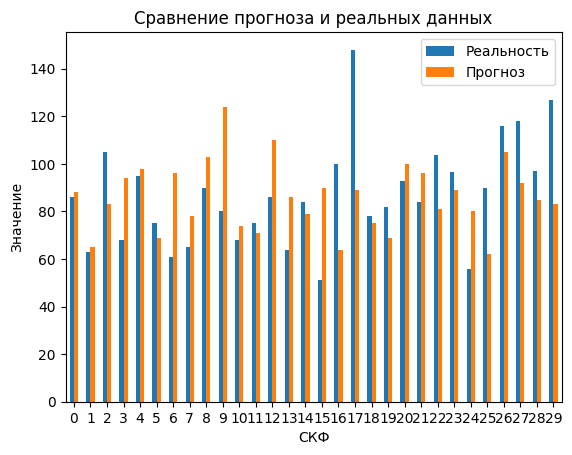

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score, mean_absolute_error
# from sklearn.preprocessing import OneHotEncoder

# X = data[['возраст','время_пережатия_аорты','холестерин']]
# y = data['скф_расч.']
# encoder = OneHotEncoder(sparse=False)
# X_encoded = encoder.fit_transform(X[['холестерин']])
# X_processed = pd.DataFrame(X_encoded, columns=[0, 1])
# X_processed[['возраст', 'время_пережатия_аорты']] = X[['возраст', 'время_пережатия_аорты']]
# X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.15, random_state=42)
# model = LinearRegression()
# model.fit(X_train.dropna(), y_train.dropna())
# y_pred = model.predict(X_test)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

X = data[['возраст', 'время_пережатия_аорты']]
y = data['скф_расч.']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LinearRegression()
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_pred=list(y_pred.astype(int))

f= pd.DataFrame({'расчёт': y_pred})


new = pd.concat([data, f], axis=1)

new=new[['скф_расч.','расчёт']].dropna()

new = new.rename(columns={'скф_расч.': 'Реальность','расчёт': 'Прогноз'})



new.plot(kind='bar', rot=0)


plt.title('Сравнение прогноза и реальных данных')
plt.xlabel('СКФ')
plt.ylabel('Значение')

# Покажите график
plt.show()



<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d0ceb3eb-1f51-4363-a332-ef7f5cbba9de' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>